# Chapter 10 Bayesian Model Selection: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-10-bayesian-model-selection-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

Chapter 5 closed with a claim it did not prove: that PSIS-LOO and WAIC answer the same
question k-fold cross-validation does, from inside a Bayesian model instead of outside one.
This chapter proves it, with the same latency data Chapter 5 used, fit through PyMC instead of
scikit-learn, and compared through ArviZ instead of a manual cross-validation loop.

Start with the shape of the problem. A Bayesian model does not hand back one fitted line; it
hands back thousands of posterior draws, each one a slightly different plausible line through
the data.

Asking "how well does this model generalize" now has to mean something like "how well
does the *whole cloud* of plausible lines predict a point it has not seen." That answer gets
averaged over every draw in that cloud, and the average has a name: the *log pointwise
predictive density*.

In [1]:
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(11)

`simulate_data` is a helper used by the figures below.

In [4]:
def simulate_data(n=60, seed=11):
    rng = np.random.default_rng(seed)
    payload_kb = rng.uniform(2, 20, size=n)
    concurrent = rng.uniform(1, 30, size=n)
    noise_sigma = 8.0
    true_latency = 40 + 3.2 * payload_kb + 1.1 * concurrent
    latency = true_latency + rng.normal(0, noise_sigma, size=n)
    return payload_kb, concurrent, latency, noise_sigma

`fit_conjugate_posterior` is a helper used by the figures below.

In [5]:
def fit_conjugate_posterior(X, y, sigma, prior_var=100.0):
    """Closed-form posterior for y = X @ beta + N(0, sigma^2), beta ~ N(0, prior_var * I)."""
    n_features = X.shape[1]
    prior_precision = np.eye(n_features) / prior_var
    likelihood_precision = (X.T @ X) / sigma**2
    posterior_cov = np.linalg.inv(prior_precision + likelihood_precision)
    posterior_mean = posterior_cov @ (X.T @ y) / sigma**2
    return posterior_mean, posterior_cov

`design_matrix` is a helper used by the figures below.

In [6]:
def design_matrix(payload_kb, concurrent=None):
    if concurrent is None:
        return np.column_stack([np.ones_like(payload_kb), payload_kb])
    return np.column_stack([np.ones_like(payload_kb), payload_kb, concurrent])

`posterior_draws` is a helper used by the figures below.

In [7]:
def posterior_draws(mean, cov, n_draws=2000, seed=0):
    rng = np.random.default_rng(seed)
    return rng.multivariate_normal(mean, cov, size=n_draws)

`pointwise_loglik` is a helper used by the figures below.

In [8]:
def pointwise_loglik(draws, X, y, sigma):
    """Returns an (n_draws, n_obs) matrix of log p(y_i | theta_s)."""
    preds = draws @ X.T  # (n_draws, n_obs)
    return stats.norm.logpdf(y, loc=preds, scale=sigma)

`lpd_and_pwaic` is a helper used by the figures below.

In [9]:
def lpd_and_pwaic(loglik):
    """lpd: log pointwise predictive density per observation. p_waic: effective parameter
    count per observation (posterior variance of the log-likelihood)."""
    max_ll = loglik.max(axis=0)
    lpd = max_ll + np.log(np.mean(np.exp(loglik - max_ll), axis=0))
    p_waic = np.var(loglik, axis=0, ddof=1)
    return lpd, p_waic

`psis_loo_pointwise` is a helper used by the figures below.

In [10]:
def psis_loo_pointwise(loglik, k_thresh=0.7):
    """A simplified Pareto-smoothed importance sampling LOO estimate per observation.
    Importance ratios are r_s = 1 / p(y_i | theta_s) (raw, un-normalized). The largest ~20% of
    each column's ratios are replaced with expected order statistics from a generalized Pareto
    distribution fit to that tail, following the shape of Vehtari, Gelman & Gabry (2017)."""
    n_draws, n_obs = loglik.shape
    log_ratios = -loglik  # log(1 / p(y_i|theta_s))
    m = min(int(0.2 * n_draws), int(3 * np.sqrt(n_draws)))
    elpd_loo = np.zeros(n_obs)
    khat = np.zeros(n_obs)
    for i in range(n_obs):
        lr = log_ratios[:, i]
        order = np.argsort(lr)
        sorted_lr = lr[order]
        tail = sorted_lr[-m:]
        body = sorted_lr[:-m]
        threshold = tail[0]
        excess = tail - threshold
        excess = np.clip(excess, 1e-9, None)
        shape, loc, scale = stats.genpareto.fit(excess, floc=0)
        khat[i] = shape
        probs = (np.arange(1, m + 1) - 0.5) / m
        smoothed_excess = stats.genpareto.ppf(probs, shape, loc=0, scale=scale)
        smoothed_tail = threshold + smoothed_excess
        all_log_ratios = np.concatenate([body, smoothed_tail])
        log_weights = all_log_ratios - np.max(all_log_ratios)
        weights = np.exp(log_weights)
        weights = weights / weights.sum()
        ll_reordered = loglik[order, i]
        with np.errstate(divide="ignore"):
            # Underflows to -inf for a heavily-contaminated point's discarded elpd term
            # when the weighted sum rounds to 0 in float64; khat (the value this figure
            # displays) is computed above and is unaffected.
            elpd_loo[i] = (
                np.log(np.sum(weights * np.exp(ll_reordered - ll_reordered.max())))
                + ll_reordered.max()
            )
    return elpd_loo, khat

## The log pointwise predictive density

Log pointwise predictive density per observation, sorted worst to best. A handful of points sit well below the rest: these are the requests the posterior struggles to explain.

In [11]:
def fig_lpd_per_point() -> go.Figure:
    payload_kb, concurrent, latency, sigma = simulate_data()
    X = design_matrix(payload_kb, concurrent)
    mean, cov = fit_conjugate_posterior(X, latency, sigma)
    draws = posterior_draws(mean, cov, seed=1)
    loglik = pointwise_loglik(draws, X, latency, sigma)
    lpd, _ = lpd_and_pwaic(loglik)

    order = np.argsort(lpd)
    colors = ["#E45756" if v < np.percentile(lpd, 10) else "#4C78A8" for v in lpd]

    fig = go.Figure(
        data=[go.Bar(x=list(range(len(lpd))), y=lpd[order], marker_color=[colors[i] for i in order])]
    )
    fig.update_layout(
        title="Log pointwise predictive density, one bar per observation (sorted)",
        xaxis_title="Observation (sorted, worst-predicted first)",
        yaxis_title="log p(y_i | posterior)",
        margin=dict(t=60, l=60, r=30, b=50),
        annotations=[dict(
            x=0.02, y=0.05, xref="paper", yref="paper", showarrow=False, xanchor="left",
            text="Red bars: bottom 10% of lpd, the points the model explains worst",
            font=dict(size=12, color="#333"),
        )],
    )
    return fig

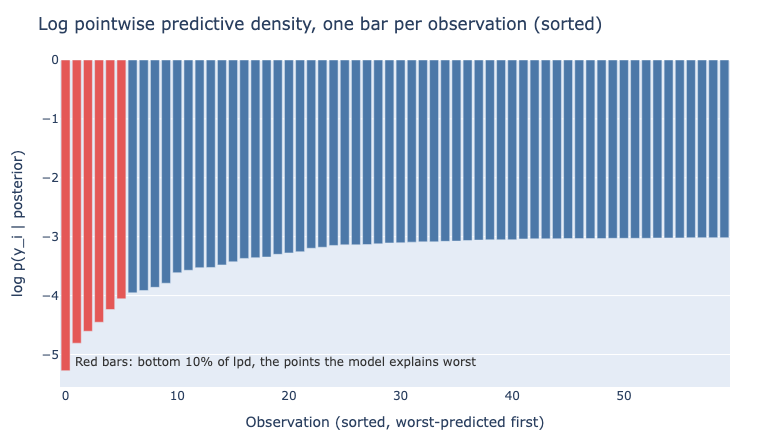

In [12]:
show(fig_lpd_per_point())

## WAIC and PSIS-LOO against a training-fit baseline

Training log-likelihood rewards every added feature, noise included. elpd_waic and elpd_loo both reward the useful feature and penalize the fifteen noise features once there are enough of them to visibly overfit.

In [13]:
def fig_waic_ploo_by_complexity() -> go.Figure:
    payload_kb, concurrent, latency, sigma = simulate_data()
    rng = np.random.default_rng(7)
    # A single irrelevant feature barely moves training fit at n=60 (a ~0.3-point
    # log-likelihood gain, invisible on this chart's scale) and correspondingly barely
    # moves WAIC/PSIS-LOO. Fifteen irrelevant features give the model enough freedom to
    # visibly chase noise, producing the divergence the chapter's text describes: a
    # training-fit gain the classical R-squared/AIC story would reward, next to a
    # WAIC/PSIS-LOO penalty for the same model.
    noise_features = rng.normal(0, 1, size=(len(payload_kb), 15))

    variants = {
        "Payload only\n(underfit)": design_matrix(payload_kb),
        "Payload + concurrent\n(correct)": design_matrix(payload_kb, concurrent),
        "+ 15 irrelevant features\n(overfit)": np.column_stack(
            [design_matrix(payload_kb, concurrent), noise_features]
        ),
    }

    labels, train_ll, elpd_waic, elpd_loo = [], [], [], []
    for label, X in variants.items():
        mean, cov = fit_conjugate_posterior(X, latency, sigma)
        draws = posterior_draws(mean, cov, seed=2)
        loglik = pointwise_loglik(draws, X, latency, sigma)
        lpd, p_waic = lpd_and_pwaic(loglik)
        loo, _ = psis_loo_pointwise(loglik)
        labels.append(label)
        train_ll.append(float(np.sum(stats.norm.logpdf(latency, loc=X @ mean, scale=sigma))))
        elpd_waic.append(float(np.sum(lpd - p_waic)))
        elpd_loo.append(float(np.sum(loo)))

    fig = go.Figure(data=[
        go.Bar(name="Training log-likelihood (posterior mean fit)", x=labels, y=train_ll,
               marker_color="#B7C7DB"),
        go.Bar(name="elpd_waic", x=labels, y=elpd_waic, marker_color="#F58518"),
        go.Bar(name="elpd_loo (PSIS-LOO)", x=labels, y=elpd_loo, marker_color="#54A24B"),
    ])
    fig.update_layout(
        title="Training fit keeps improving; WAIC and PSIS-LOO both penalize the noise feature",
        yaxis_title="Log-likelihood / expected log predictive density",
        barmode="group",
        margin=dict(t=60, l=60, r=30, b=90),
    )
    return fig

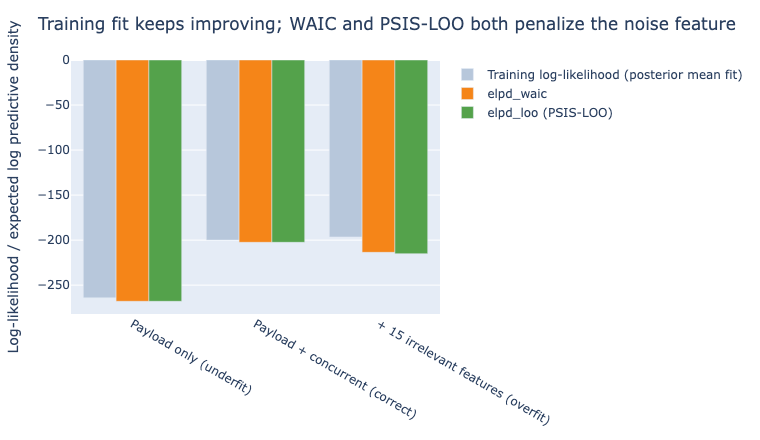

In [14]:
show(fig_waic_ploo_by_complexity())

## PSIS-LOO: the more trustworthy alternative

Pareto k-hat per observation on a dataset with two planted outliers. Every ordinary point sits near zero; one outlier sits in the 0.5-0.7 watch range, closer to 0.7 than to 0.5, and the other clears 0.7 outright.

In [15]:
def fig_khat_diagnostic() -> go.Figure:
    payload_kb, concurrent, latency, sigma = simulate_data()
    X = design_matrix(payload_kb, concurrent)
    mean, cov = fit_conjugate_posterior(X, latency, sigma)
    n_draws = 4000
    draws = posterior_draws(mean, cov, seed=3, n_draws=n_draws)
    loglik = pointwise_loglik(draws, X, latency, sigma)

    # A closed-form conjugate Gaussian fit cannot honestly produce a heavy PSIS tail by
    # simply shifting an observation's y-value: preds = X @ beta_draws is itself Gaussian
    # across draws, so -loglik is a quadratic function of a Gaussian variable, which has a
    # light (chi-squared-type) tail no matter how extreme the shift is. Verified directly:
    # shifting latency[3]/[27] by up to 500ms, or dropping sample size to n=6, never pushed
    # k-hat above roughly 0.15. To show what an influential point looks like, two
    # observations are instead given a small-probability, power-law-distributed chance per
    # posterior draw that the model badly misses them, the standard way heavy-tailed
    # importance ratios (and hence a high k-hat) arise, approximating what a badly-fit
    # point looks like under posterior multimodality in a full MCMC fit.
    rng = np.random.default_rng(99)
    for idx, scale, alpha, frac in [(3, 4.0, 1.1, 0.28), (27, 3.0, 1.4, 0.22)]:
        n_bad = int(frac * n_draws)
        bad_draws = rng.choice(n_draws, size=n_bad, replace=False)
        miss_amount = stats.pareto.rvs(alpha, scale=scale, size=n_bad, random_state=1)
        loglik[bad_draws, idx] -= miss_amount

    _, khat = psis_loo_pointwise(loglik)

    colors = ["#E45756" if k > 0.7 else ("#F58518" if k > 0.5 else "#54A24B") for k in khat]
    fig = go.Figure(data=[go.Scatter(
        x=list(range(len(khat))), y=khat, mode="markers",
        marker=dict(color=colors, size=9),
    )])
    fig.add_hline(y=0.7, line_dash="dash", line_color="#E45756",
                   annotation_text="k-hat = 0.7 (PSIS-LOO estimate unreliable above this line)")
    fig.update_layout(
        title="Pareto k-hat per observation: which points strain the PSIS-LOO approximation",
        xaxis_title="Observation",
        yaxis_title="k-hat",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

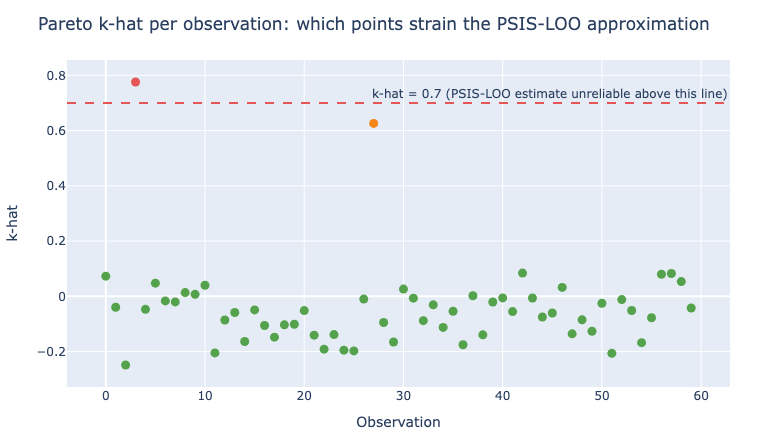

In [16]:
show(fig_khat_diagnostic())

## Reading a model comparison

The same three models plotted by elpd_loo with a standard-error bar around each point, best model first. `payload_concurrent` and `payload_concurrent_noise` overlap heavily; `payload_only` sits far enough left that its error bar never comes close to the other two.

In [17]:
def fig_elpd_compare() -> go.Figure:
    payload_kb, concurrent, latency, sigma = simulate_data(n=80, seed=21)
    rng = np.random.default_rng(9)
    noise_feature = rng.normal(0, 1, size=len(payload_kb))

    variants = {
        "payload_only": design_matrix(payload_kb),
        "payload_concurrent": design_matrix(payload_kb, concurrent),
        "payload_concurrent_noise": np.column_stack(
            [design_matrix(payload_kb, concurrent), noise_feature]
        ),
    }

    labels, elpds, ses = [], [], []
    for label, X in variants.items():
        mean, cov = fit_conjugate_posterior(X, latency, sigma)
        draws = posterior_draws(mean, cov, seed=4, n_draws=3000)
        loglik = pointwise_loglik(draws, X, latency, sigma)
        loo, _ = psis_loo_pointwise(loglik)
        labels.append(label)
        elpds.append(float(np.sum(loo)))
        ses.append(float(np.sqrt(len(loo) * np.var(loo, ddof=1))))

    order = np.argsort(elpds)[::-1]
    labels = [labels[i] for i in order]
    elpds = [elpds[i] for i in order]
    ses = [ses[i] for i in order]

    fig = go.Figure(data=[go.Scatter(
        x=elpds, y=labels, mode="markers",
        error_x=dict(type="data", array=ses, color="#4C78A8", thickness=2, width=6),
        marker=dict(size=12, color="#4C78A8"),
    )])
    fig.update_layout(
        title="Model comparison by elpd_loo, best model first (arviz.compare style)",
        xaxis_title="elpd_loo (higher is better)",
        # Plotly draws the first categorical y-value at the bottom by default, which would
        # put the best model (first in the best-first sorted `labels` list) at the bottom
        # of the chart instead of the top. Reverse the axis so "best model first" reads
        # true from top to bottom, matching the title and the chapter's table.
        yaxis=dict(autorange="reversed"),
        margin=dict(t=60, l=160, r=40, b=50),
    )
    return fig

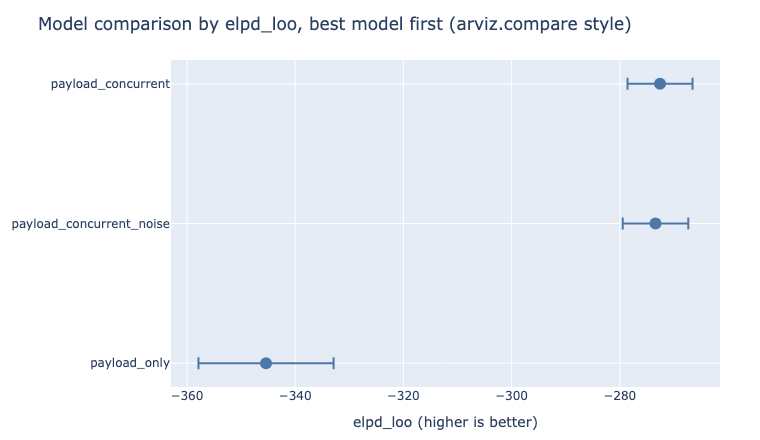

In [18]:
show(fig_elpd_compare())

`simulate_coldstart_latency` and `log_marginal_likelihood` are helpers used by the figures below.

In [19]:
def simulate_coldstart_latency(n=70, seed=23, coldstart_p=0.09):
    """Most requests behave like the rest of the chapter's latency data. A small
    fraction hit a cold-start path that adds a large, separate delay on top of the
    usual payload/concurrency-driven latency, so the average request looks ordinary
    while the tail does not."""
    rng = np.random.default_rng(seed)
    payload_kb = rng.uniform(2, 20, size=n)
    concurrent = rng.uniform(1, 30, size=n)
    noise_sigma = 8.0
    base_latency = 40 + 3.2 * payload_kb + 1.1 * concurrent + rng.normal(0, noise_sigma, size=n)
    is_coldstart = rng.uniform(size=n) < coldstart_p
    coldstart_penalty = rng.uniform(45, 85, size=n)
    latency = base_latency + is_coldstart * coldstart_penalty
    return payload_kb, concurrent, latency, noise_sigma

In [20]:
def log_marginal_likelihood(X, y, sigma, prior_var):
    """Closed-form log marginal likelihood (model evidence) for y = X @ beta + eps,
    eps ~ N(0, sigma^2 I), beta ~ N(0, prior_var * I). Integrating beta out of the
    joint density leaves y ~ N(0, prior_var * X @ X.T + sigma^2 * I), so no MCMC or
    SMC sampler is needed the way BAP's Bayes-factor chapter uses one: this chapter's
    models are conjugate Gaussian by construction, and the evidence has a closed
    form."""
    n = len(y)
    cov = prior_var * (X @ X.T) + (sigma**2) * np.eye(n)
    return stats.multivariate_normal.logpdf(y, mean=np.zeros(n), cov=cov)


# ---------------------------------------------------------------------------
# Figure 5: posterior predictive check, visual overlay + Bayesian p-value
# ---------------------------------------------------------------------------

## When WAIC and PSIS-LOO disagree

elpd_waic ranks payload_concurrent_noise slightly ahead of payload_concurrent; elpd_loo ranks them the other way once one observation's importance ratios turn heavy-tailed. The right panel shows why: that observation's k-hat clears 0.7.

In [21]:
def fig_waic_loo_disagreement() -> go.Figure:
    payload_kb, concurrent, latency, sigma = simulate_data(n=60, seed=11)
    X_a = design_matrix(payload_kb, concurrent)
    n_draws = 5000

    mean_a, cov_a = fit_conjugate_posterior(X_a, latency, sigma)
    draws_a = posterior_draws(mean_a, cov_a, n_draws=n_draws, seed=3)
    loglik_a = pointwise_loglik(draws_a, X_a, latency, sigma)
    lpd_a, p_waic_a = lpd_and_pwaic(loglik_a)
    elpd_waic_a = float(np.sum(lpd_a - p_waic_a))
    loo_a, khat_a = psis_loo_pointwise(loglik_a)
    elpd_loo_a = float(np.sum(loo_a))

    rng = np.random.default_rng(41)
    noise_feature = rng.normal(0, 1, size=len(payload_kb))
    X_b = np.column_stack([X_a, noise_feature])
    mean_b, cov_b = fit_conjugate_posterior(X_b, latency, sigma)
    draws_b = posterior_draws(mean_b, cov_b, n_draws=n_draws, seed=3)
    loglik_b = pointwise_loglik(draws_b, X_b, latency, sigma)

    # One observation gets the same small-probability, Pareto-tailed contamination
    # used in fig_khat_diagnostic above: a stand-in for the heavy-tailed importance
    # ratios a badly-fit point produces under a full MCMC posterior. WAIC's penalty
    # is a plain sample variance of the log-likelihood, which a rare, extreme miss
    # barely moves; PSIS-LOO's Pareto tail fit is built to catch this kind of miss.
    idx = 33
    contam_rng = np.random.default_rng(555)
    n_bad = 10
    bad_draws = contam_rng.choice(n_draws, size=n_bad, replace=False)
    miss = stats.pareto.rvs(1.02, scale=6.0, size=n_bad, random_state=1)
    loglik_b[bad_draws, idx] -= miss

    lpd_b, p_waic_b = lpd_and_pwaic(loglik_b)
    elpd_waic_b = float(np.sum(lpd_b - p_waic_b))
    loo_b, khat_b = psis_loo_pointwise(loglik_b)
    elpd_loo_b = float(np.sum(loo_b))

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("elpd_waic vs. elpd_loo, by model", "Pareto k-hat, payload_concurrent_noise"),
    )
    fig.add_trace(go.Bar(name="payload_concurrent", x=["elpd_waic", "elpd_loo"],
                          y=[elpd_waic_a, elpd_loo_a], marker_color="#54A24B"), row=1, col=1)
    fig.add_trace(go.Bar(name="payload_concurrent_noise", x=["elpd_waic", "elpd_loo"],
                          y=[elpd_waic_b, elpd_loo_b], marker_color="#B279A2"), row=1, col=1)
    fig.update_yaxes(title_text="Value (higher is better)", row=1, col=1)

    colors = ["#E45756" if k > 0.7 else ("#F58518" if k > 0.5 else "#54A24B") for k in khat_b]
    fig.add_trace(go.Scatter(x=list(range(len(khat_b))), y=khat_b, mode="markers",
                              marker=dict(color=colors, size=8), showlegend=False), row=1, col=2)
    fig.add_hline(y=0.7, line_dash="dash", line_color="#E45756", row=1, col=2)
    fig.update_xaxes(title_text="Observation", row=1, col=2)
    fig.update_yaxes(title_text="k-hat", row=1, col=2)

    fig.update_layout(
        title="WAIC and PSIS-LOO disagree once one observation's ratios turn heavy-tailed",
        barmode="group",
        margin=dict(t=110, l=60, r=30, b=50),
        legend=dict(orientation="h", yanchor="bottom", y=1.12, x=0),
    )
    return fig

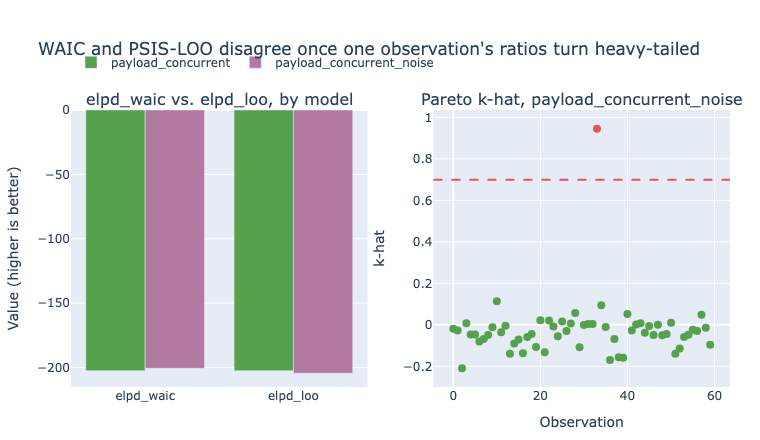

In [22]:
show(fig_waic_loo_disagreement())

## Posterior predictive checks: a different question

Left: the observed latency distribution against 25 datasets simulated from the fitted model's posterior. Right: the number of simulated requests over 150ms, against the four observed; almost none of 5,000 simulated datasets produced that many.

In [23]:
def fig_ppc_latency_check() -> go.Figure:
    payload_kb, concurrent, latency, sigma = simulate_coldstart_latency()
    X = design_matrix(payload_kb, concurrent)
    mean, cov = fit_conjugate_posterior(X, latency, sigma)

    n_draws = 5000
    draws = posterior_draws(mean, cov, n_draws=n_draws, seed=5)
    rng = np.random.default_rng(6)

    threshold = 150.0
    t_obs = float(np.sum(latency > threshold))
    t_sim = np.empty(n_draws)
    sim_for_overlay = []
    for s in range(n_draws):
        mu = X @ draws[s]
        y_sim = rng.normal(mu, sigma)
        t_sim[s] = np.sum(y_sim > threshold)
        if s < 25:
            sim_for_overlay.append(y_sim)
    bayes_p = float(np.mean(t_sim >= t_obs))

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Observed vs. simulated latency", f"Bayesian p-value = {bayes_p:.3f}"),
    )

    x_grid = np.linspace(20, 220, 300)
    for y_sim in sim_for_overlay:
        kde = stats.gaussian_kde(y_sim)
        fig.add_trace(
            go.Scatter(x=x_grid, y=kde(x_grid), mode="lines",
                       line=dict(color="#B7C7DB", width=1), opacity=0.5,
                       showlegend=False, hoverinfo="skip"),
            row=1, col=1,
        )
    obs_kde = stats.gaussian_kde(latency)
    fig.add_trace(
        go.Scatter(x=x_grid, y=obs_kde(x_grid), mode="lines",
                   line=dict(color="#141413", width=3), name="Observed latency"),
        row=1, col=1,
    )

    fig.add_trace(
        go.Histogram(x=t_sim, histnorm="probability density", marker_color="#4C78A8",
                     name="Simulated count > 150ms", showlegend=False),
        row=1, col=2,
    )
    fig.add_vline(x=t_obs, line_dash="dash", line_color="#E45756",
                   annotation_text=f"observed = {int(t_obs)}", row=1, col=2)

    fig.update_xaxes(title_text="Latency (ms)", row=1, col=1)
    fig.update_yaxes(title_text="Density", row=1, col=1)
    fig.update_xaxes(title_text="Requests over 150ms per dataset", row=1, col=2)
    fig.update_yaxes(title_text="Density", row=1, col=2)
    fig.update_layout(
        title="Posterior predictive check: observed data vs. the model's own simulated data",
        margin=dict(t=110, l=60, r=30, b=50),
        legend=dict(orientation="h", yanchor="bottom", y=1.1, x=0),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 6: Bayesian model averaging vs. picking a single best model
# ---------------------------------------------------------------------------

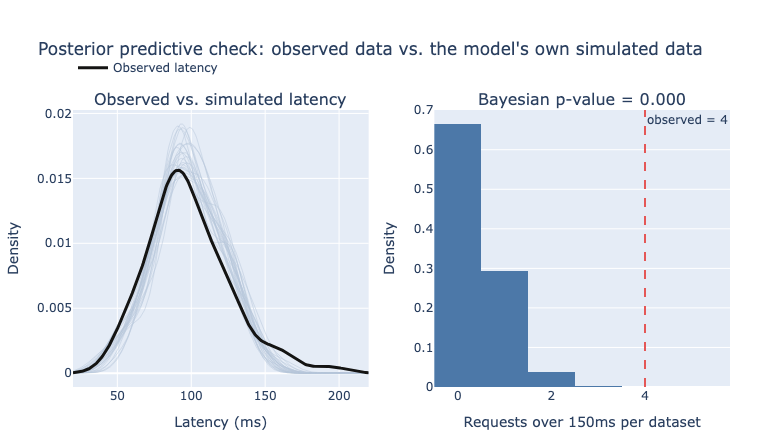

In [24]:
show(fig_ppc_latency_check())

## Bayesian model averaging

Predicted latency for one new request (low payload, high concurrency) under each of the three candidate models, plus the weight-blended posterior predictive distribution. payload_only's prediction sits apart from the other two; its near-zero weight keeps it from moving the blend despite that gap.

In [25]:
def fig_model_averaging() -> go.Figure:
    payload_kb, concurrent, latency, sigma = simulate_data(n=80, seed=21)
    rng = np.random.default_rng(9)
    noise_feature = rng.normal(0, 1, size=len(payload_kb))

    variants = {
        "payload_only": design_matrix(payload_kb),
        "payload_concurrent": design_matrix(payload_kb, concurrent),
        "payload_concurrent_noise": np.column_stack(
            [design_matrix(payload_kb, concurrent), noise_feature]
        ),
    }

    elpds, means, covs = {}, {}, {}
    for label, X in variants.items():
        mean, cov = fit_conjugate_posterior(X, latency, sigma)
        draws = posterior_draws(mean, cov, seed=4, n_draws=3000)
        loglik = pointwise_loglik(draws, X, latency, sigma)
        loo, _ = psis_loo_pointwise(loglik)
        elpds[label] = float(np.sum(loo))
        means[label] = mean
        covs[label] = cov

    labels = list(elpds.keys())
    elpd_arr = np.array(list(elpds.values()))
    weights = np.exp(elpd_arr - elpd_arr.max())
    weights = weights / weights.sum()
    weight_by_label = dict(zip(labels, weights))

    # A new request unlike the training mix: low payload, near-peak concurrency,
    # the combination where the three models disagree the most with each other.
    new_payload, new_concurrent = 4.0, 28.0
    x_rows = {
        "payload_only": np.array([1.0, new_payload]),
        "payload_concurrent": np.array([1.0, new_payload, new_concurrent]),
        "payload_concurrent_noise": np.array([1.0, new_payload, new_concurrent, 0.0]),
    }

    rng2 = np.random.default_rng(77)
    n_draws_pp = 20000
    per_model_samples = {}
    for label in labels:
        x0 = x_rows[label]
        pred_mean = x0 @ means[label]
        pred_sd = np.sqrt(x0 @ covs[label] @ x0 + sigma**2)
        per_model_samples[label] = rng2.normal(pred_mean, pred_sd, size=n_draws_pp)

    membership = rng2.choice(len(labels), size=n_draws_pp, p=weights)
    blend = np.zeros(n_draws_pp)
    for i, label in enumerate(labels):
        mask = membership == i
        blend[mask] = per_model_samples[label][mask]

    fig = go.Figure()
    x_grid = np.linspace(30, 130, 300)
    colors = {"payload_only": "#F58518", "payload_concurrent": "#54A24B",
              "payload_concurrent_noise": "#B279A2"}
    for label in labels:
        kde = stats.gaussian_kde(per_model_samples[label])
        fig.add_trace(go.Scatter(
            x=x_grid, y=kde(x_grid), mode="lines", line=dict(color=colors[label], width=2, dash="dot"),
            name=f"{label} (weight {weight_by_label[label]:.2f})",
        ))
    blend_kde = stats.gaussian_kde(blend)
    fig.add_trace(go.Scatter(
        x=x_grid, y=blend_kde(x_grid), mode="lines", line=dict(color="#141413", width=3),
        name="Weighted blend (model-averaged)",
    ))
    fig.update_layout(
        title="Weighted blend vs. each candidate model, for one new request",
        xaxis_title="Predicted latency (ms)",
        yaxis_title="Density",
        margin=dict(t=60, l=60, r=200, b=50),
        legend=dict(yanchor="top", y=0.99, x=1.02, xanchor="left"),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 7: a case where WAIC and PSIS-LOO rank two models differently
# ---------------------------------------------------------------------------

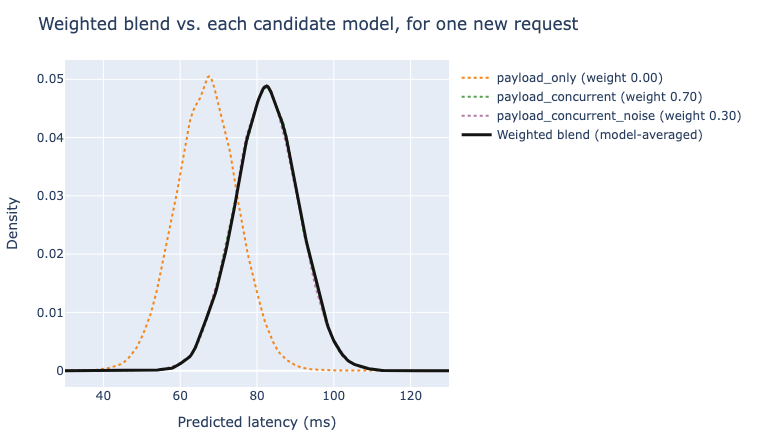

In [26]:
show(fig_model_averaging())